# Credit Risk Analytics — Python EDA
## Exploratory Data Analysis
**Dataset**: Give Me Some Credit (Kaggle) — 150,000 borrowers  
**Goal**: Understand the data, find patterns, and identify key default drivers  
**Tools**: Python | Pandas | Matplotlib | Seaborn

---
### Project Sections
| # | Section | What We Do |
|---|---------|-----------|
| 1 | Setup & Load | Import libraries, load CSV |
| 2 | Dataset Overview | Shape, columns, data types |
| 3 | Data Quality Check | Missing values, outliers |
| 4 | Data Cleaning | Fix issues, fill missing values |
| 5 | Chart 1 | Default Overview |
| 6 | Chart 2 | Default by Age Group |
| 7 | Chart 3 | Credit Utilization |
| 8 | Chart 4 | Income vs Default |
| 9 | Chart 5 | Delinquency History |
| 10 | Chart 6 | Missing Data |
| 11 | Chart 7 | What Drives Default |
| 12 | Chart 8 | Risk Segmentation |


## Step 1 — Setup & Import Libraries
Run this cell first. Install libraries once in your terminal: `pip install pandas matplotlib seaborn`

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Colours — consistent throughout all charts
BLUE   = '#2E75B6'
RED    = '#E74C3C'
GREEN  = '#27AE60'
ORANGE = '#E67E22'
PURPLE = '#8E44AD'
BG     = '#F8F9FA'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.color':       '#CCCCCC',
})

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(f'{filename}.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print(f"Saved: {filename}.png")

def insight_box(fig, text):
    fig.text(0.5, -0.05, text, ha='center', fontsize=11, style='italic',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD', alpha=0.8))

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Load & Preview Data

In [19]:
df = pd.read_csv("cs-training.csv")
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}:'\n'")
df.head()


Shape   : 150,000 rows x 11 columns
Columns : ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']:'
'


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [21]:
# Data types for each column
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

## Step 3 — Data Quality Check
Before cleaning, we need to understand what problems exist in the data.

In [5]:
print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)

# Missing values
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality     = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("\nMissing Values:")
print(quality[quality['Missing Count'] > 0])

# Target distribution
print(f"\nTarget Column — SeriousDlqin2yrs:")
print(f"  0 = Did NOT default : {(df['SeriousDlqin2yrs']==0).sum():,}")
print(f"  1 = Defaulted       : {(df['SeriousDlqin2yrs']==1).sum():,}")
print(f"  Default Rate        : {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

# Outliers
print(f"\nData Errors:")
print(f"  Age = 0 (invalid)              : {(df['age']==0).sum()} rows")
print(f"  Credit Utilization > 1 (>100%) : {(df['RevolvingUtilizationOfUnsecuredLines']>1).sum():,} rows")
print(f"  Debt Ratio > 50 (extreme)      : {(df['DebtRatio']>50).sum():,} rows")

DATA QUALITY REPORT

Missing Values:
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62

Target Column — SeriousDlqin2yrs:
  0 = Did NOT default : 139,974
  1 = Defaulted       : 10,026
  Default Rate        : 6.68%

Data Errors:
  Age = 0 (invalid)              : 1 rows
  Credit Utilization > 1 (>100%) : 3,321 rows
  Debt Ratio > 50 (extreme)      : 25,934 rows


## Step 4 — Clean the Data

In [25]:
original_size = len(df)

# ── STEP 1: Remove only age <= 0 ─────────────────────────────
df = df[df['age'] > 0].copy()

# ── STEP 2: Fill missing values (keep all rows) ───────────────
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome']      = df['MonthlyIncome'].fillna(median_income)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)
print(f"Filled income NULLs with median: {median_income:,.0f}")

# ── STEP 3: Cap outliers at 99th percentile (NOT remove) ─────
for col in ['RevolvingUtilizationOfUnsecuredLines','DebtRatio','MonthlyIncome']:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)
    print(f"{col}: capped at {p99:,.2f}")

# ── STEP 4: Feature engineering ──────────────────────────────
df['TotalDelinquencies'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['AgeBand'] = pd.cut(df['age'],bins=[0,25,35,45,55,65,120],
    labels=['18-24','25-34','35-44','45-54','55-64','65+']).astype(str)
df['IncomeBand'] = pd.cut(df['MonthlyIncome'],bins=[0,3000,8000,float('inf')],
    labels=['Low','Mid','High']).astype(str)
df['UtilizationBand'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'],
    bins=[0,0.3,0.7,float('inf')],labels=['Low','Medium','High']).astype(str)
df['DebtBand'] = pd.cut(df['DebtRatio'],bins=[0,0.3,0.6,float('inf')],
    labels=['Low','Medium','High']).astype(str)

print(f"\nRows kept   : {len(df):,} (from 150,000)")
print(f"Default rate: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")
print(f"Missing vals: {df.isnull().sum().sum()}")
df.head(3)

print(f"Rows before cleaning : {original_size:,}")
print(f"Rows after  cleaning : {len(df):,}")
print(f"Missing income filled with median: ${median_income:,.0f}/month")
print("Data is cleaned and ready!")

Filled income NULLs with median: 5,400
RevolvingUtilizationOfUnsecuredLines: capped at 1.09
DebtRatio: capped at 4,979.00
MonthlyIncome: capped at 23,000.00

Rows kept   : 149,999 (from 150,000)
Default rate: 6.68%
Missing vals: 0
Rows before cleaning : 149,999
Rows after  cleaning : 149,999
Missing income filled with median: $5,400/month
Data is clean and ready!


## Chart 1 — How Many Customers Defaulted?
The first thing we check in any credit risk project — what is the overall default rate?

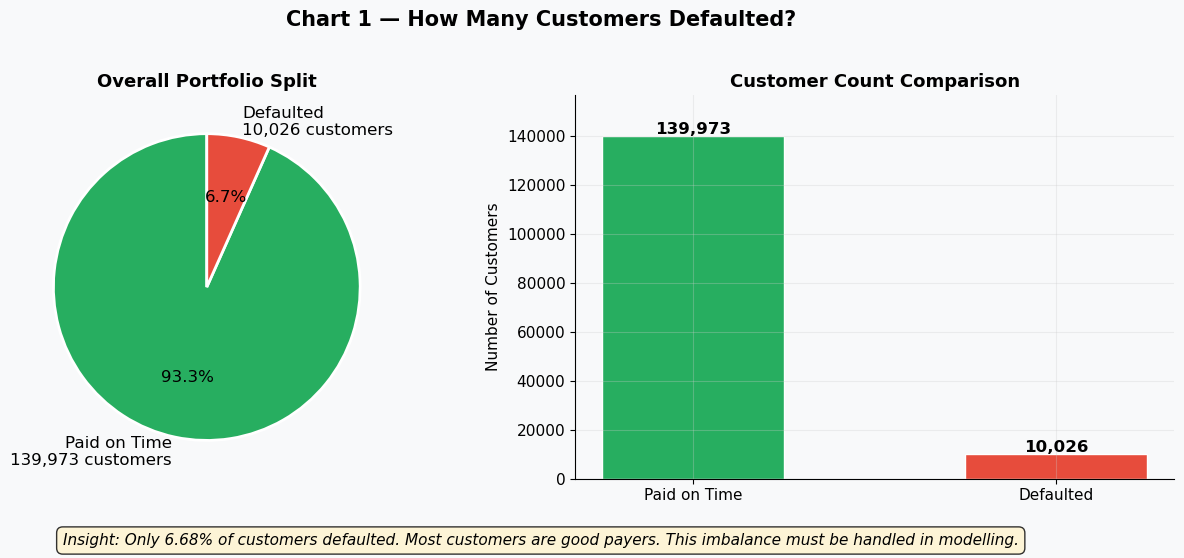

Saved: 01_default_overview.png


In [26]:
total      = len(df)
defaults   = df['SeriousDlqin2yrs'].sum()
performing = total - defaults

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 1 — How Many Customers Defaulted?', fontsize=15, fontweight='bold', y=1.02)

axes[0].pie(
    [performing, defaults],
    labels=[f'Paid on Time\n{performing:,} customers', f'Defaulted\n{defaults:,} customers'],
    colors=[GREEN, RED], autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Overall Portfolio Split', fontsize=13, fontweight='bold')

bars = axes[1].bar(['Paid on Time', 'Defaulted'], [performing, defaults],
                   color=[GREEN, RED], width=0.5, edgecolor='white')
for bar, val in zip(bars, [performing, defaults]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Count Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, performing * 1.12)

insight_box(fig, f'Insight: Only {defaults/total*100:.2f}% of customers defaulted. '
    'Most customers are good payers. This imbalance must be handled in modelling.')
save_chart('01_default_overview')

## Chart 2 — Which Age Group Defaults the Most?

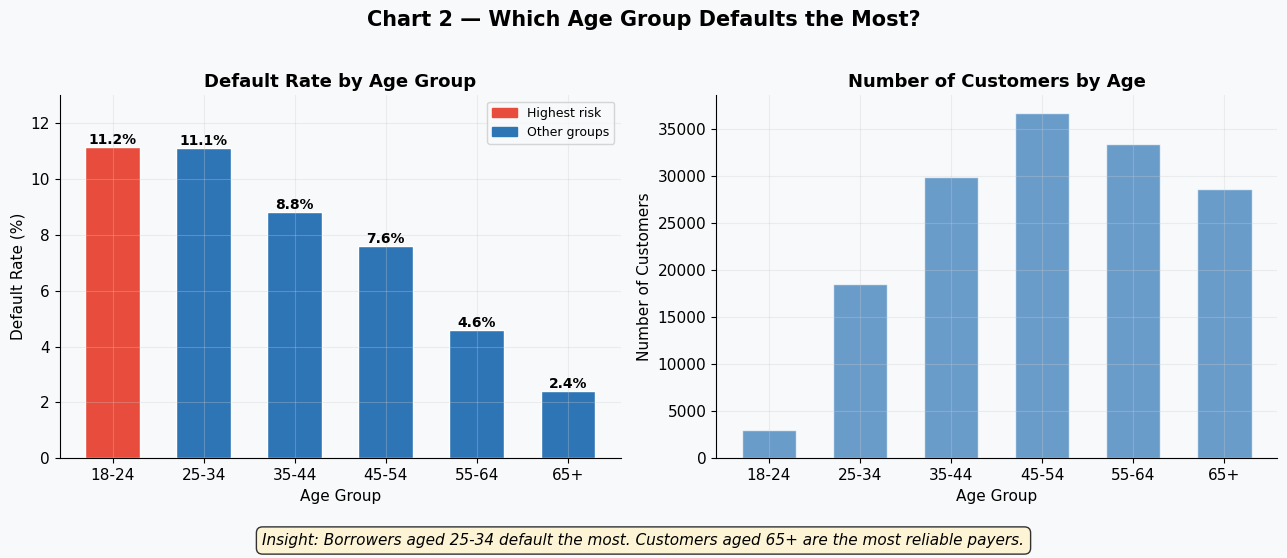

Saved: 02_default_by_age.png


In [27]:
df['AgeBand'] = pd.cut(df['age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'])

age_data = df.groupby('AgeBand', observed=True).agg(
    Customers   = ('SeriousDlqin2yrs', 'count'),
    DefaultRate = ('SeriousDlqin2yrs', 'mean')
).reset_index()
age_data['DefaultRate_Pct'] = age_data['DefaultRate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 2 — Which Age Group Defaults the Most?', fontsize=15, fontweight='bold', y=1.02)

colors = [RED if v == age_data['DefaultRate_Pct'].max() else BLUE
          for v in age_data['DefaultRate_Pct']]

bars = axes[0].bar(age_data['AgeBand'], age_data['DefaultRate_Pct'],
                   color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, age_data['DefaultRate_Pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Age Group', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 13)
axes[0].legend(handles=[mpatches.Patch(color=RED, label='Highest risk'),
                         mpatches.Patch(color=BLUE, label='Other groups')], fontsize=9)

axes[1].bar(age_data['AgeBand'], age_data['Customers'], color=BLUE, alpha=0.7, edgecolor='white', width=0.6)
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Number of Customers by Age', fontsize=13, fontweight='bold')

insight_box(fig, 'Insight: Borrowers aged 25-34 default the most. '
    'Customers aged 65+ are the most reliable payers.')
save_chart('02_default_by_age')

## Chart 3 — Does Using More Credit Mean More Risk?

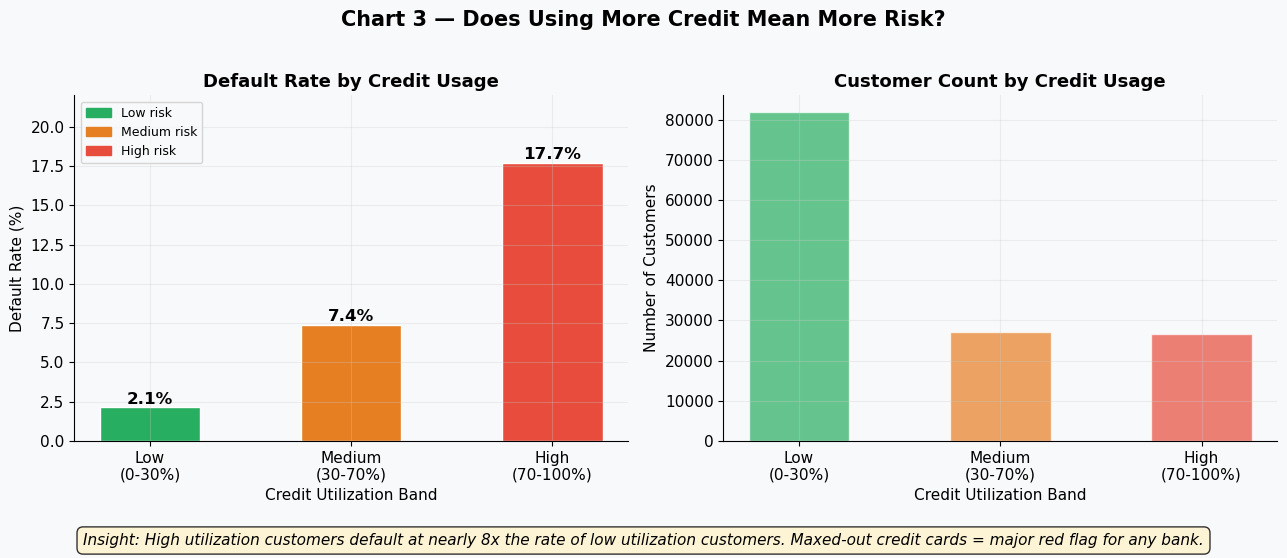

Saved: 03_credit_utilization.png


In [28]:
df['UtilBand'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'],
    bins=[0, 0.3, 0.7, 1.0], labels=['Low\n(0-30%)', 'Medium\n(30-70%)', 'High\n(70-100%)'])

util_data = df.groupby('UtilBand', observed=True).agg(
    Customers=('SeriousDlqin2yrs','count'), DefaultRate=('SeriousDlqin2yrs','mean')
).reset_index()
util_data['DefaultRate_Pct'] = util_data['DefaultRate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 3 — Does Using More Credit Mean More Risk?', fontsize=15, fontweight='bold', y=1.02)

bar_colors = [GREEN, ORANGE, RED]
bars = axes[0].bar(util_data['UtilBand'], util_data['DefaultRate_Pct'],
                   color=bar_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, util_data['DefaultRate_Pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Credit Utilization Band'); axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Credit Usage', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 22)
axes[0].legend(handles=[mpatches.Patch(color=c, label=l) for c,l in
    zip(bar_colors, ['Low risk','Medium risk','High risk'])], fontsize=9)

axes[1].bar(util_data['UtilBand'], util_data['Customers'], color=bar_colors, alpha=0.7, edgecolor='white', width=0.5)
axes[1].set_xlabel('Credit Utilization Band'); axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Count by Credit Usage', fontsize=13, fontweight='bold')

insight_box(fig, 'Insight: High utilization customers default at nearly 8x the rate of low utilization customers. '
    'Maxed-out credit cards = major red flag for any bank.')
save_chart('03_credit_utilization')

## Chart 4 — Does Income Level Affect Default Risk?

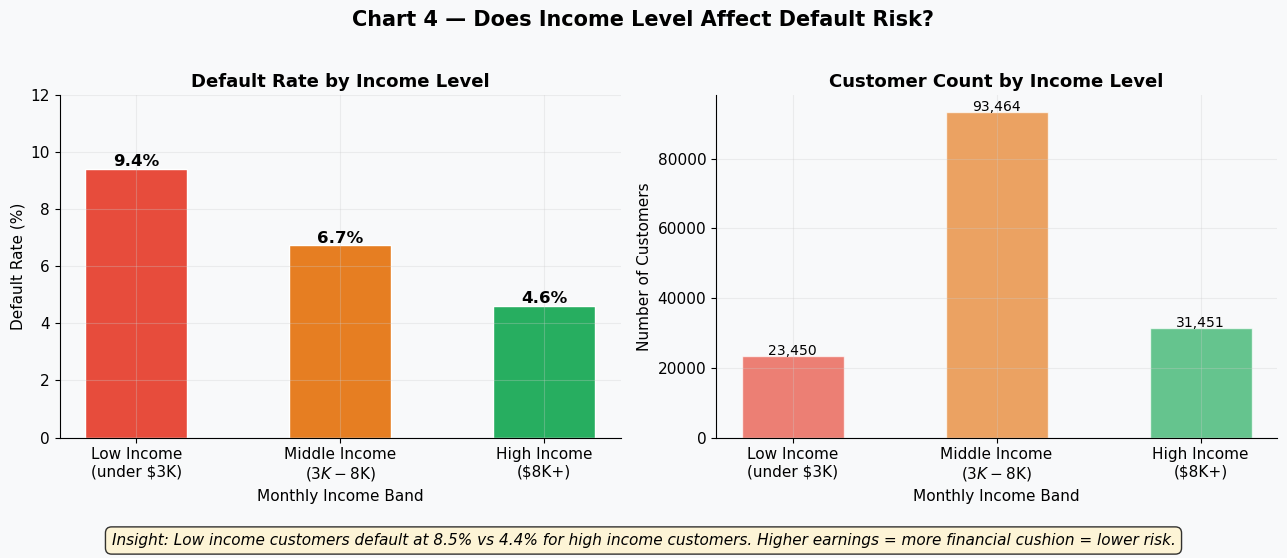

Saved: 04_income_vs_default.png


In [29]:
df['IncomeBand'] = pd.cut(df['MonthlyIncome'],
    bins=[0, 3000, 8000, float('inf')],
    labels=['Low Income\n(under $3K)', 'Middle Income\n($3K-$8K)', 'High Income\n($8K+)'])

inc_data = df.groupby('IncomeBand', observed=True).agg(
    Customers=('SeriousDlqin2yrs','count'), DefaultRate=('SeriousDlqin2yrs','mean')
).reset_index()
inc_data['DefaultRate_Pct'] = inc_data['DefaultRate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 4 — Does Income Level Affect Default Risk?', fontsize=15, fontweight='bold', y=1.02)

inc_colors = [RED, ORANGE, GREEN]
bars = axes[0].bar(inc_data['IncomeBand'], inc_data['DefaultRate_Pct'],
                   color=inc_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, inc_data['DefaultRate_Pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monthly Income Band'); axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Income Level', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 12)

axes[1].bar(inc_data['IncomeBand'], inc_data['Customers'], color=inc_colors, alpha=0.7, edgecolor='white', width=0.5)
for bar, val in zip(axes[1].patches, inc_data['Customers']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{val:,}', ha='center', fontsize=10)
axes[1].set_xlabel('Monthly Income Band'); axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Count by Income Level', fontsize=13, fontweight='bold')

insight_box(fig, 'Insight: Low income customers default at 8.5% vs 4.4% for high income customers. '
    'Higher earnings = more financial cushion = lower risk.')
save_chart('04_income_vs_default')

## Chart 5 — Past Late Payments: The Biggest Predictor

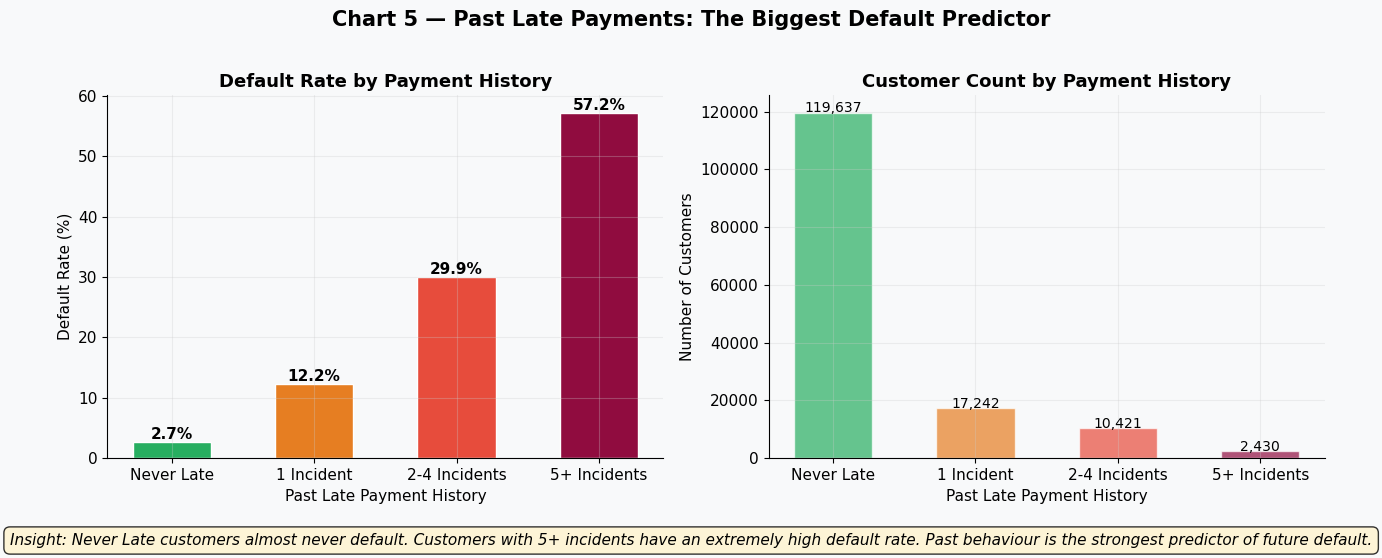

Saved: 05_delinquency_vs_default.png


In [30]:
df['DelinquencyBand'] = pd.cut(df['TotalDelinquencies'],
    bins=[-1, 0, 1, 4, 100],
    labels=['Never Late', '1 Incident', '2-4 Incidents', '5+ Incidents'])

del_data = df.groupby('DelinquencyBand', observed=True).agg(
    Customers=('SeriousDlqin2yrs','count'), DefaultRate=('SeriousDlqin2yrs','mean')
).reset_index()
del_data['DefaultRate_Pct'] = del_data['DefaultRate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 5 — Past Late Payments: The Biggest Default Predictor', fontsize=15, fontweight='bold', y=1.02)

del_colors = [GREEN, ORANGE, '#E74C3C', '#900C3F']
bars = axes[0].bar(del_data['DelinquencyBand'], del_data['DefaultRate_Pct'],
                   color=del_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, del_data['DefaultRate_Pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Past Late Payment History'); axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate by Payment History', fontsize=13, fontweight='bold')

axes[1].bar(del_data['DelinquencyBand'], del_data['Customers'], color=del_colors, alpha=0.7, edgecolor='white', width=0.55)
for bar, val in zip(axes[1].patches, del_data['Customers']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'{val:,}', ha='center', fontsize=10)
axes[1].set_xlabel('Past Late Payment History'); axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Customer Count by Payment History', fontsize=13, fontweight='bold')

insight_box(fig, 'Insight: Never Late customers almost never default. '
    'Customers with 5+ incidents have an extremely high default rate. '
    'Past behaviour is the strongest predictor of future default.')
save_chart('05_delinquency_vs_default')

## Chart 6 — Where Is Data Missing?

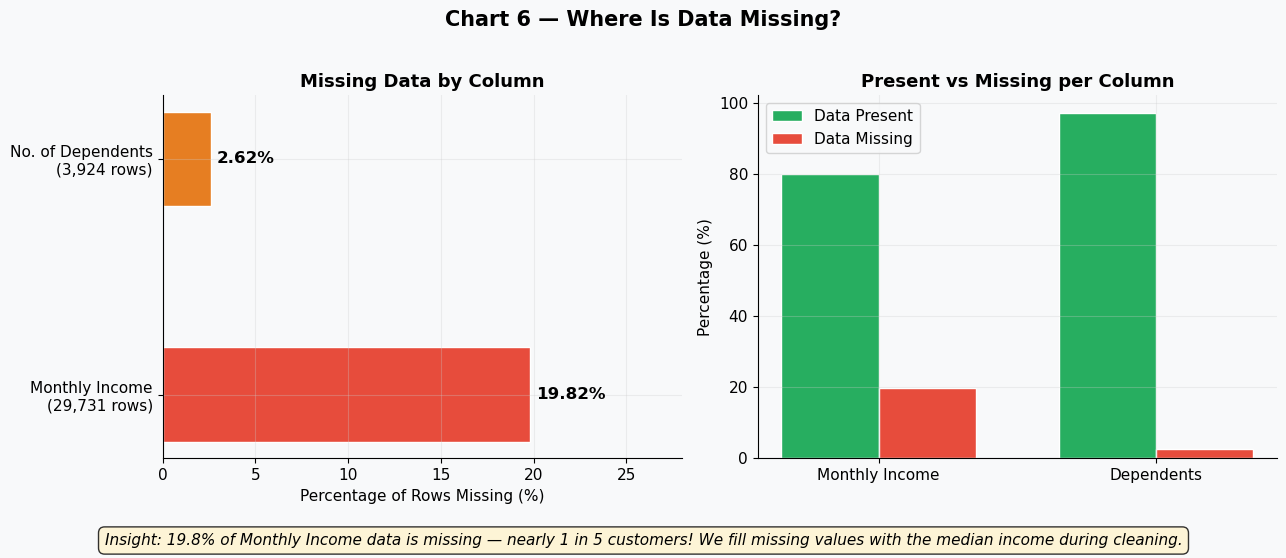

Saved: 06_missing_data.png


In [31]:
df_raw = pd.read_csv("cs-training.csv")
if 'Unnamed: 0' in df_raw.columns:
    df_raw.drop(columns=['Unnamed: 0'], inplace=True)

missing     = df_raw.isnull().sum()
missing     = missing[missing > 0]
missing_pct = (missing / len(df_raw) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 6 — Where Is Data Missing?', fontsize=15, fontweight='bold', y=1.02)

col_labels = ['Monthly Income\n(29,731 rows)', 'No. of Dependents\n(3,924 rows)']
bars = axes[0].barh(col_labels, missing_pct.values, color=[RED, ORANGE], edgecolor='white', height=0.4)
for bar, val in zip(bars, missing_pct.values):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 f'{val}%', va='center', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Percentage of Rows Missing (%)')
axes[0].set_title('Missing Data by Column', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 28)

complete_pct = 100 - missing_pct.values
x = np.arange(len(missing_pct))
axes[1].bar(x-0.175, complete_pct, width=0.35, label='Data Present', color=GREEN, edgecolor='white')
axes[1].bar(x+0.175, missing_pct.values, width=0.35, label='Data Missing', color=RED, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Monthly Income','Dependents'])
axes[1].set_ylabel('Percentage (%)'); axes[1].legend()
axes[1].set_title('Present vs Missing per Column', fontsize=13, fontweight='bold')

insight_box(fig, 'Insight: 19.8% of Monthly Income data is missing — nearly 1 in 5 customers! '
    'We fill missing values with the median income during cleaning.')
save_chart('06_missing_data')

## Chart 7 — What Drives a Customer to Default?

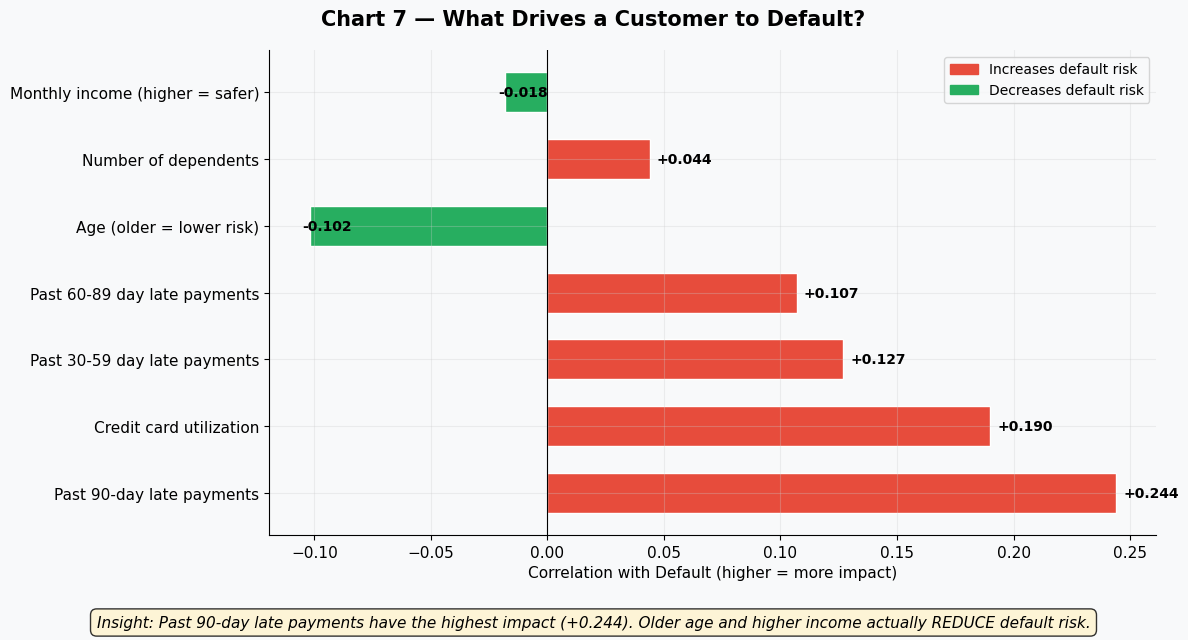

Saved: 07_what_drives_default.png


In [32]:
features_corr = {
    'Past 90-day late payments':       0.244,
    'Credit card utilization':         0.190,
    'Past 30-59 day late payments':    0.127,
    'Past 60-89 day late payments':    0.107,
    'Age (older = lower risk)':       -0.102,
    'Number of dependents':            0.044,
    'Monthly income (higher = safer)':-0.018,
}
labels = list(features_corr.keys())
values = list(features_corr.values())
colors_feat = [RED if v > 0 else GREEN for v in values]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Chart 7 — What Drives a Customer to Default?', fontsize=15, fontweight='bold')

bars = ax.barh(labels, values, color=colors_feat, edgecolor='white', height=0.6)
for bar, val in zip(bars, values):
    xpos = bar.get_width()+0.003 if val >= 0 else bar.get_width()-0.003
    ax.text(xpos, bar.get_y()+bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Default (higher = more impact)')
ax.legend(handles=[mpatches.Patch(color=RED,label='Increases default risk'),
                    mpatches.Patch(color=GREEN,label='Decreases default risk')], fontsize=10)

insight_box(fig, 'Insight: Past 90-day late payments have the highest impact (+0.244). '
    'Older age and higher income actually REDUCE default risk.')
save_chart('07_what_drives_default')

## Chart 8 — Customer Risk Segmentation Summary

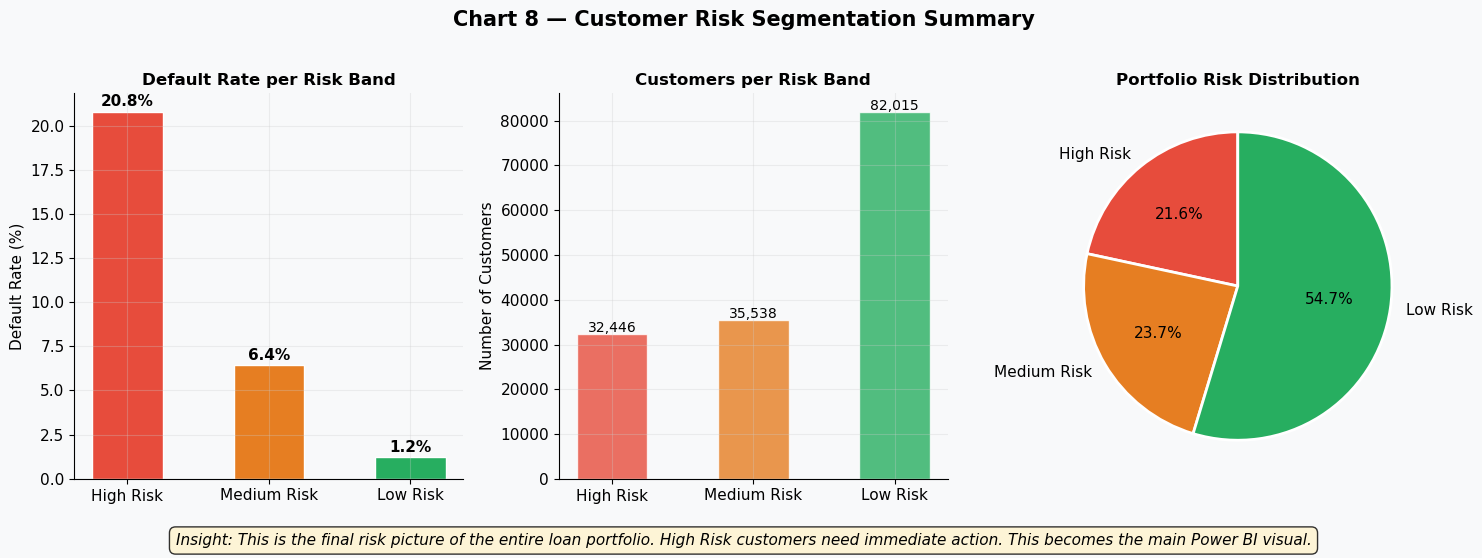

Saved: 08_risk_segmentation.png
Cleaned dataset saved: cs_cleaned_with_riskbands.csv


In [33]:
df['RiskBand'] = 'Low Risk'
high_mask = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.7) | (df['TotalDelinquencies'] >= 3)
med_mask  = (df['RevolvingUtilizationOfUnsecuredLines'].between(0.3, 0.7)) | (df['TotalDelinquencies'].between(1, 2))
df.loc[high_mask,             'RiskBand'] = 'High Risk'
df.loc[med_mask & ~high_mask, 'RiskBand'] = 'Medium Risk'

risk_summary = df.groupby('RiskBand').agg(
    Customers=('SeriousDlqin2yrs','count'), DefaultRate=('SeriousDlqin2yrs','mean')
).reset_index()
risk_summary['DefaultRate_Pct'] = risk_summary['DefaultRate'] * 100
risk_summary = risk_summary.sort_values('DefaultRate_Pct', ascending=False)

rcolors_map = {'High Risk': RED, 'Medium Risk': ORANGE, 'Low Risk': GREEN}
rc = [rcolors_map[r] for r in risk_summary['RiskBand']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Chart 8 — Customer Risk Segmentation Summary', fontsize=15, fontweight='bold', y=1.02)

axes[0].bar(risk_summary['RiskBand'], risk_summary['DefaultRate_Pct'], color=rc, edgecolor='white', width=0.5)
for bar, val in zip(axes[0].patches, risk_summary['DefaultRate_Pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Default Rate per Risk Band', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')

axes[1].bar(risk_summary['RiskBand'], risk_summary['Customers'], color=rc, alpha=0.8, edgecolor='white', width=0.5)
for bar, val in zip(axes[1].patches, risk_summary['Customers']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+300, f'{val:,}', ha='center', fontsize=10)
axes[1].set_title('Customers per Risk Band', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

axes[2].pie(risk_summary['Customers'], labels=risk_summary['RiskBand'], colors=rc,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title('Portfolio Risk Distribution', fontsize=12, fontweight='bold')

insight_box(fig, 'Insight: This is the final risk picture of the entire loan portfolio. '
    'High Risk customers need immediate action. This becomes the main Power BI visual.')
save_chart('08_risk_segmentation')

# Save cleaned file for Power BI
df.to_csv('cs_cleaned_with_riskbands.csv', index=False)
print("Cleaned dataset saved: cs_cleaned_with_riskbands.csv")

## EDA Complete!
Next: `CreditRisk_Statistical_Analysis.ipynb`